In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import datetime
import json
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import wandb
from accelerate.commands.config.update import description
from transformers import (
    AutoModelForMaskedLM,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

def set_seed(seed=42) -> None:
    """Set all seeds to make results reproducible (deterministic mode).
    When seed is a false-y value or not supplied, disables deterministic mode."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

from dotenv import load_dotenv
load_dotenv()

True

In [4]:
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(i).name)

# os.environ["MY_VARIABLE"] = "my_value"


NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000


## Load trained model from wandb

In [6]:
def load_model_from_wandb(model_path):
    run = wandb.init()
    artifact = run.use_artifact(model_path, type='model')
    artifact_dir = artifact.download()
    model = AutoModelForMaskedLM.from_pretrained(artifact_dir)
    return model, artifact_dir

def load_model_from_local(model_path):
    model = AutoModelForMaskedLM.from_pretrained(model_path)
    return model, model_path

def load_model(model_path, use_wandb=True):
    if use_wandb:
        return load_model_from_wandb(model_path)
    else:
        return load_model_from_local(model_path)
    
# checking if two hugging face models are same or not
model_from_wandb, model_from_wandb_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-ytxjrbhy:v1")
model_from_local, model_from_local_path = load_model_from_local("/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/tmp/models/timestamp_20241216_18-41-39/nasa-impact/nasa-smd-ibm-v0.1/checkpoint-23000")
# model_from_local, model_from_local_path = load_model_from_local("/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/model_outputs/20241211_15-10-59/model")


# Compare the state_dicts
are_models_identical = all(
    torch.equal(param1, param2) 
    for param1, param2 in zip(model_from_wandb.state_dict().values(), model_from_local.state_dict().values())
)

print(f"Are the models identical? {are_models_identical}")



wandb: Downloading large artifact model-ytxjrbhy:v1, 475.71MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:1.6


Are the models identical? True


## Load Data and split identiacally

In [8]:
from ..preprocess_data import preprocess_dataset
with open("../config.json", "r") as file:
    config = json.load(file)

data_src = "local"
n_rows = None
lm_dataset, tokenizer, data_collator = preprocess_dataset(
        config.get("input"),
        data_src,
        n_rows,
    )

ImportError: attempted relative import with no known parent package

## Make Predictions on train and test data

In [12]:
from utils import generate_inference

test_inference_df = generate_inference(
        lm_dataset["test"],
        tokenizer,
        model_from_local_path,
        top_k=config.get("output").get("inference").get("top_k"),
        n_predictions=None
)

train_inference_df = generate_inference(
        lm_dataset["train"],
        tokenizer,
        model_from_local_path,
        top_k=config.get("output").get("inference").get("top_k"),
        n_predictions=None
)


Map:   0%|          | 0/28416 [00:00<?, ? examples/s]

Device set to use cuda:0


Map:   0%|          | 0/214832 [00:00<?, ? examples/s]

Device set to use cuda:0


In [13]:
train_inference_df.to_parquet("tmp/inferences/train_inference.parquet")
test_inference_df.to_parquet("tmp/inferences/test_inference.parquet")

In [14]:
# # Find the document with the maximum tokens without modifying the dataset
# max_tokens_document = max(lm_dataset["validation"], key=lambda x: len(x['input_ids']))

# # Print details
# print(f"Number of tokens: {len(max_tokens_document['input_ids'])}")
# print(f"Document: {max_tokens_document}")

# decoded_text = tokenizer.decode(max_tokens_document['input_ids'], skip_special_tokens=True)
# print(decoded_text)

Number of tokens: 500
Document: {'input_ids': [0, 29429, 14259, 149, 18845, 434, 428, 918, 5402, 149, 228, 1703, 223, 14259, 2595, 149, 1165, 149, 2298, 2055, 31811, 883, 35, 149, 2856, 59, 149, 2001, 6620, 149, 3817, 322, 149, 30981, 1979, 46931, 1849, 149, 3132, 149, 40266, 873, 149, 37199, 149, 29783, 25182, 149, 1285, 7802, 149, 13237, 30934, 149, 14080, 46931, 1849, 149, 37199, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 2263, 1930, 149, 13990, 5378, 149, 8246, 567, 149, 6339, 11605, 149, 29783, 25182, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 2263, 1930, 149, 8246, 567, 149, 6339, 11605, 149, 1285, 7802, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 3566, 7245, 313, 149, 3566, 15371, 149, 9712, 1441, 149, 3400, 149, 2298, 666, 21081, 35, 149, 13793, 18042, 149, 9712, 4031, 149, 25182, 149, 14761, 4970, 24817, 149, 20879, 215, 12532, 149, 13990, 5378, 149, 3104, 305, 2076, 149, 3173, 17, 26714, 8207, 149, 4691, 149, 5478, 206, 4691, 149, 40266, 873, 149, 14080, 46931, 184

In [1]:
import pandas as pd
train_inference_df = pd.read_parquet("tmp/inferences/train_inference.parquet")
test_inference_df = pd.read_parquet("tmp/inferences/test_inference.parquet")

In [2]:
test_inference_df.head()

,input,target,top1,top2,top3
0,<s> skip to main content missions search all...,,"{'score': 1.0, 'token': 149, 'token_str': ' '}","{'score': 0.0, 'token': 723, 'token_str': ' '}","{'score': 0.0, 'token': 1459, 'token_str': ' |'}"
1,"<s> pia15670: oppia region, three ways target...",x,"{'score': 1.0, 'token': 1119, 'token_str': ' x'}","{'score': 0.0, 'token': 2017, 'token_str': ' ×'}","{'score': 0.0, 'token': 309, 'token_str': ' by'}"
2,<s> atmosphere heat human presence land li...,events,"{'score': 0.9999, 'token': 2422, 'token_str': ...","{'score': 0.0, 'token': 14048, 'token_str': ' ...","{'score': 0.0, 'token': 26455, 'token_str': ' ..."
3,department described the winter of 2007-2008 ...,the,"{'score': 1.0, 'token': 192, 'token_str': ' the'}","{'score': 0.0, 'token': 352, 'token_str': ' th...","{'score': 0.0, 'token': 764, 'token_str': ' our'}"
4,<s> skip to content nasa power | docs nasa p...,allows,"{'score': 0.2002, 'token': 15349, 'token_str':...","{'score': 0.1885, 'token': 13150, 'token_str':...","{'score': 0.1511, 'token': 3141, 'token_str': ..."


# Compute distribution of probablity for train and test for top1,2,3

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

def plot_score_distribution(inference_df, dataset_split):
    """
    Plot the distribution of top scores in the dataset using histograms with proportions.
    
    Args:
        inference_df (pd.DataFrame): Inference dataframe containing 'top' score columns.
        dataset_split (str): Name of the dataset split (e.g., Train, Test).
    """
    _inference_df = inference_df.copy()
    top_scores_str = [c for c in inference_df.columns if "top" in c]

    # Safely extract scores
    for col in top_scores_str:
        _inference_df[col] = inference_df[col].apply(
            lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0
        )

    # Melt the DataFrame for plotting
    _inference_df = _inference_df.melt(
        value_vars=top_scores_str,
        var_name='Category',
        value_name='Scores'
    )
    _inference_df = _inference_df.dropna(subset=['Scores'])

    # Check if data is sufficient for plotting
    if _inference_df.empty:
        print("No valid data available for plotting.")
        return

    # Plot Histogram with Proportions
    plot = sns.histplot(
        data=_inference_df,
        x='Scores',
        hue='Category',
        bins=50,
        stat='proportion',  # Show proportions on the y-axis
        element='step',     # Step appearance for clarity
        fill=True,
        alpha=0.5,          # Transparency for better overlap visualization
        common_norm=False   # Normalize each category independently
    )

    # Title and Labels
    plt.title(f'{dataset_split} Distribution of Scores for {", ".join(top_scores_str)}')
    plt.xlabel('Scores')
    plt.ylabel('Proportion')

    # Ensure legend is displayed
    handles, labels = plot.get_legend_handles_labels()
    if handles and labels:
        plt.legend(handles=handles, labels=labels, title='Category', loc='upper right', fontsize='small')
    else:
        print("Warning: Legend could not be generated. Please verify 'Category' column values.")
    
    # Display the plot
    plt.tight_layout()
    plt.show()




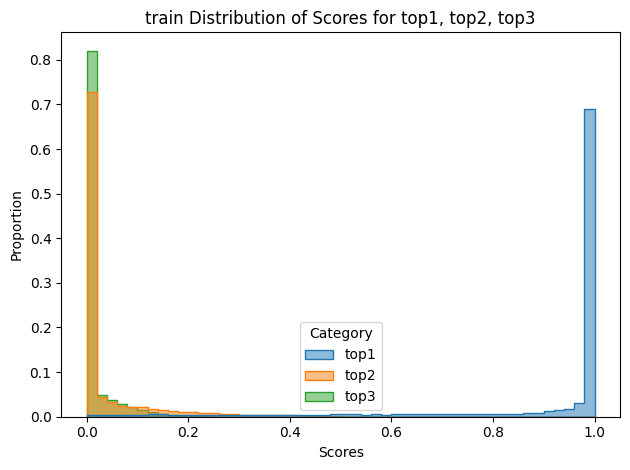

In [4]:
plot_score_distribution(train_inference_df, "train")

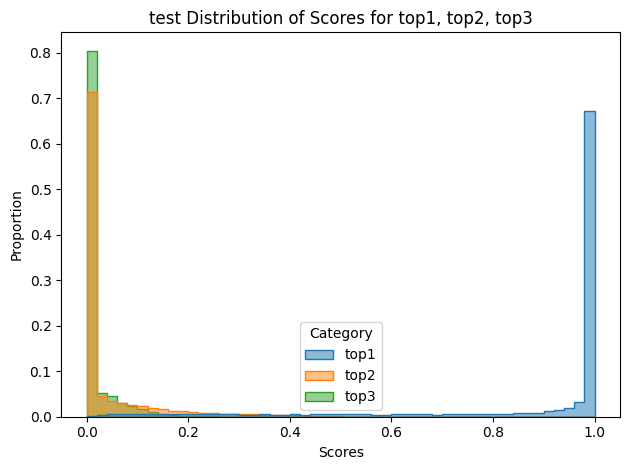

In [5]:
plot_score_distribution(test_inference_df, "test")

## Compare test-train distributions of scores

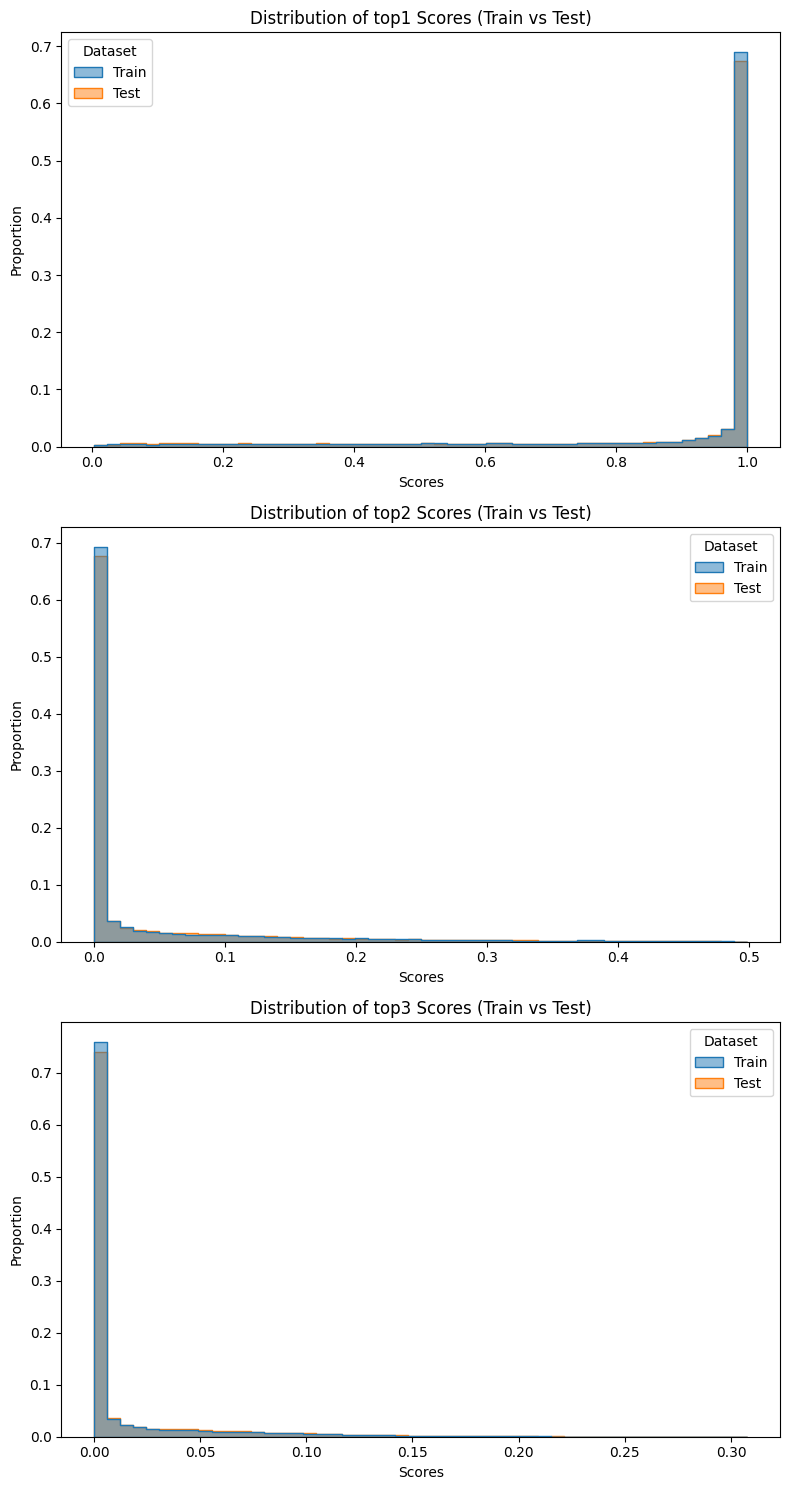

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_histogram_distribution(train_inference_df, test_inference_df):
    """
    Compare top1, top2, and top3 scores from train and test datasets using histograms
    with proportions on the y-axis.
    
    Args:
        train_inference_df (pd.DataFrame): Inference dataframe for training data.
        test_inference_df (pd.DataFrame): Inference dataframe for testing data.
    """
    # Extract 'top' score columns
    top_n = [c for c in train_inference_df.columns if "top" in c]
    
    if not top_n:
        raise ValueError("No 'top' columns found in the datasets.")
    
    # Extract scores
    train_scores = {
        col: train_inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)
        for col in top_n
    }
    test_scores = {
        col: test_inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)
        for col in top_n
    }
    
    # Create subplots
    fig, axs = plt.subplots(len(top_n), 1, figsize=(8, 5 * len(top_n)))
    axs = axs if len(top_n) > 1 else [axs]
    
    for i, col in enumerate(top_n):
        comparison_df = pd.DataFrame({
            'Train': train_scores[col],
            'Test': test_scores[col]
        }).melt(var_name='Dataset', value_name='Scores')
        
        # Histogram plot with proportions
        plot = sns.histplot(
            data=comparison_df,
            x='Scores',
            hue='Dataset',
            bins=50,
            stat='proportion',  # Show proportions on the y-axis
            element='step',     # Step appearance for clarity
            fill=True,
            alpha=0.5,          # Transparency for overlap visibility
            common_norm=False,  # Normalize each dataset independently
            ax=axs[i]
        )
        
        axs[i].set_title(f'Distribution of {col} Scores (Train vs Test)')
        axs[i].set_xlabel('Scores')
        axs[i].set_ylabel('Proportion')
        
    # Adjust layout
    plt.tight_layout()
    plt.show()


plot_histogram_distribution(train_inference_df, test_inference_df)

## Generate accuracy for top 1, top2, top3 predictions

In [7]:
def get_accuracy(inference_df):
    _inference_df = inference_df.copy()
    top_n = [c for c in _inference_df.columns if "top" in c]

    _inference_df['predictions'] = _inference_df.apply(lambda row: [row[col].get('token_str') for col in top_n], axis=1)

    for i, top_i in enumerate(top_n):
        _inference_df[f'{top_i}_correct'] = _inference_df.apply(lambda row: int(row['target'] in row['predictions'][:i+1]), axis=1)

    accuracy = {top_i: float(round(_inference_df[f'{top_i}_correct'].mean(), 4)) for top_i in top_n}

    return accuracy

train_accuracy = get_accuracy(train_inference_df)
test_accuracy = get_accuracy(test_inference_df)

In [8]:
print("Train Accuracy:")
print(train_accuracy)
print()
print("Test Accuracy:")
print(test_accuracy)

Train Accuracy:
{'top1': 0.833, 'top2': 0.8895, 'top3': 0.9071}

Test Accuracy:
{'top1': 0.8211, 'top2': 0.8768, 'top3': 0.894}


In [9]:
train_inference_df.head()

,input,target,top1,top2,top3
0,<s> pia01368: jupiter's moon io target name: ...,.,"{'score': 0.9981, 'token': 18, 'token_str': '.'}","{'score': 0.0012, 'token': 332, 'token_str': '...","{'score': 0.0003, 'token': 5, 'token_str': '!'}"
1,<s> proposer archive data analysis instrume...,,"{'score': 0.9997, 'token': 149, 'token_str': ' '}","{'score': 0.0001, 'token': 309, 'token_str': '...","{'score': 0.0001, 'token': 30, 'token_str': ':'}"
2,", cambridge,<mask> 02138 usa. helpdesk or emai...",ma,"{'score': 0.9992, 'token': 1072, 'token_str': ...","{'score': 0.0006, 'token': 12948, 'token_str':...","{'score': 0.0, 'token': 711, 'token_str': 'ma'}"
3,<s> skip<mask> main content missions search ...,to,"{'score': 1.0, 'token': 228, 'token_str': ' to'}","{'score': 0.0, 'token': 217, 'token_str': 'to'}","{'score': 0.0, 'token': 340, 'token_str': ' fr..."
4,<s> skip to main content an official website ...,stable,"{'score': 1.0, 'token': 3642, 'token_str': ' s...","{'score': 0.0, 'token': 9864, 'token_str': 'st...","{'score': 0.0, 'token': 3706, 'token_str': ' s..."


# Average scores for each top-k for train and test datasets

In [10]:


def get_average_scores(inference_df):
    _inference_df = inference_df.copy()
    top_n = [c for c in _inference_df.columns if "top" in c]

    for col in top_n:
        _inference_df[col] = _inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)

    average_scores = {top_i: float(round(_inference_df[top_i].mean(), 4)) for top_i in top_n}

    return average_scores

train_average_scores = get_average_scores(train_inference_df)
test_average_scores = get_average_scores(test_inference_df)

print("Average Score for Train:") 
print(train_average_scores)
print("Average Score for Test:") 
print(test_average_scores)

Average Score for Train:
{'top1': 0.877, 'top2': 0.0393, 'top3': 0.0141}
Average Score for Test:
{'top1': 0.8639, 'top2': 0.0403, 'top3': 0.0151}
